# Ensemble Learning [ Voting Regressor ]
- Ensemble learning combines multiple machine learning models to create a stronger predictive model. The Voting Regressor is an ensemble method that aggregates the predictions from several base regressors by averaging their outputs.
This approach often leads to better generalization and reduced variance compared to any single model.
- Use three diverse base models:
  - Linear Regression
  - Decision Tree Regressor
  - Support Vector Regressor (SVR)
- Dataset: California Housing Prices (predicting median house value).

### Import necessary libraries for data handling, modeling, evaluation and visualization

In [74]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.model_selection import cross_validate
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.datasets import fetch_california_housing
from sklearn.metrics import accuracy_score, mean_squared_error, r2_score
from sklearn.ensemble import VotingRegressor
from sklearn.preprocessing import StandardScaler

### Load the built-in California Housing dataset

In [76]:
data = fetch_california_housing()

### About the Dataset
The California Housing dataset contains information about houses in California districts. Our goal is to predict the median house value (MedHouseVal).

In [78]:
# Create a pandas DataFrame for easier analysis
df = pd.DataFrame(data.data, columns=data.feature_names)
df['MedHouseVal'] = data.target

# Display first few rows
print("First 5 rows of the dataset:")
display(df.head())

First 5 rows of the dataset:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


### Basic dataset information

In [80]:
print("Dataset Shape:", df.shape)
print("\nStatistical Summary:")
display(df.describe())

Dataset Shape: (20640, 9)

Statistical Summary:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


### Check for missing values

In [82]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64


### Correlation Heatmap

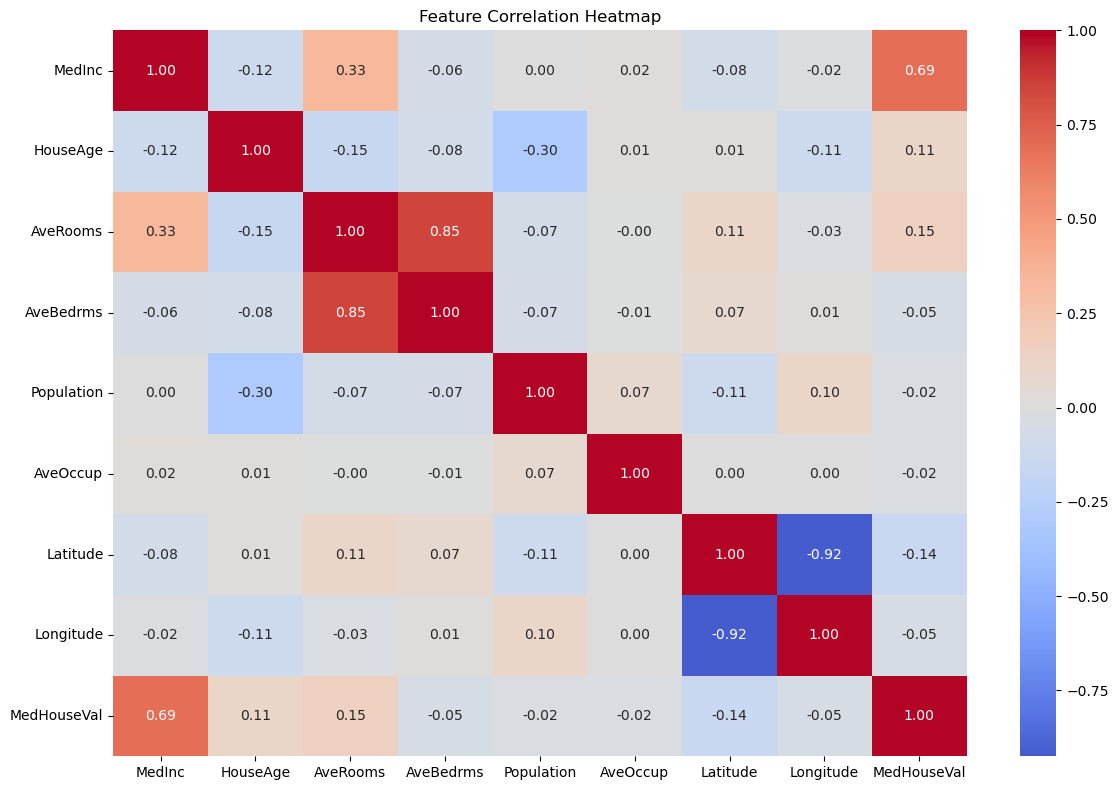

In [84]:
plt.figure(figsize=(12, 8))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()


###  Target variable distribution

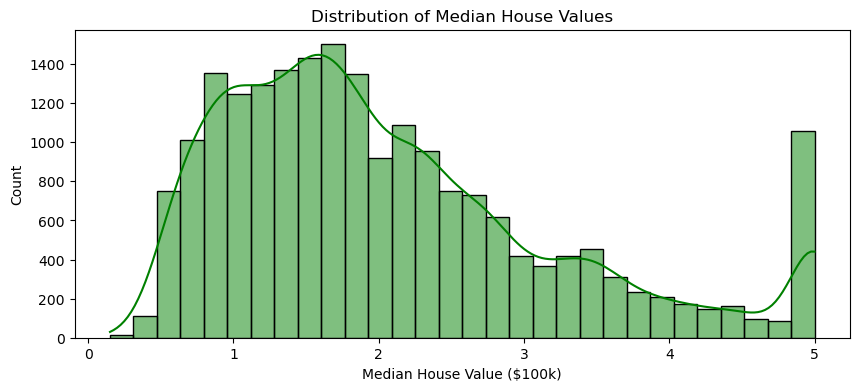

In [86]:
plt.figure(figsize=(10, 4))
sns.histplot(df['MedHouseVal'], kde=True, bins=30,color='green')
plt.title('Distribution of Median House Values')
plt.xlabel('Median House Value ($100k)')
plt.show()

#### Spliting Training and Testing Data 

In [88]:
# Separate features and target variable
X = df.drop('MedHouseVal', axis=1)
y = df['MedHouseVal']

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

Training set shape: (16512, 8)
Testing set shape: (4128, 8)


### Feature Scaling
Support Vector Regressor (SVR) is highly sensitive to feature scales. Scaling also benefits Linear Regression. Decision Trees are scale-invariant, but scale all features for consistency.

In [90]:
# Scale features using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features have been scaled successfully")

Features have been scaled successfully


### Voting Regressor - Use three diverse base models:
- Linear Regression
- Decision Tree Regressor
- Support Vector Regressor (SVR)

In [92]:
# Initialize base models
model_linear = LinearRegression()
model_tree = DecisionTreeRegressor(random_state=42)  # random_state for reproducibility
model_svr = SVR(kernel='rbf')

# Create Voting Regressor ensemble
voting_reg = VotingRegressor(
    estimators=[
        ('Linear_Regression', model_linear),
        ('Decision_Tree', model_tree),
        ('SVR', model_svr)])

### Model Training and Comparison
- Train each base model individually and the Voting Regressor ensemble. 
- This allows direct performance comparison.

Linear Regression    - MSE: 0.5559 | R2 Score: 0.5758
Decision Tree        - MSE: 0.4940 | R2 Score: 0.6230
SVR                  - MSE: 0.3570 | R2 Score: 0.7276
Voting Regressor     - MSE: 0.3414 | R2 Score: 0.7395


,Model,MSE,R2 Score
0,Linear Regression,0.5559,0.5758
1,Decision Tree,0.4940,0.6230
2,SVR,0.3570,0.7276
3,Voting Regressor,0.3414,0.7395


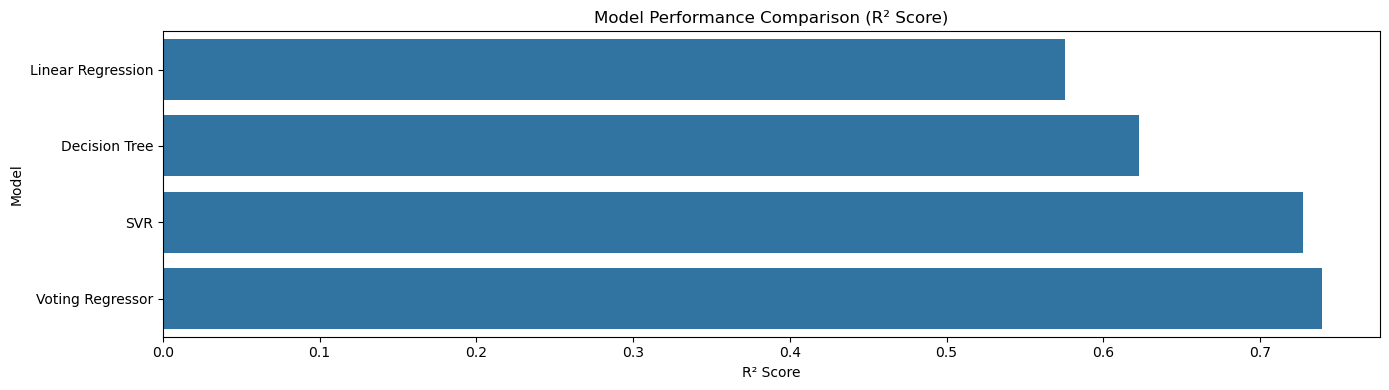

In [94]:
# Train and evaluate all models on scaled data
models = {
    'Linear Regression': model_linear,
    'Decision Tree': model_tree,
    'SVR': model_svr,
    'Voting Regressor': voting_reg
}

results = []

for name, model in models.items():
    model.fit(X_train_scaled, y_train)          # train on scaled data
    y_pred = model.predict(X_test_scaled)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    results.append({
        'Model': name,
        'MSE': round(mse, 4),
        'R2 Score': round(r2, 4)
    })
    
    print(f"{name:20} - MSE: {mse:.4f} | R2 Score: {r2:.4f}")

# Display comparison table
results_df = pd.DataFrame(results)
display(results_df)

# Suggested Graph 3: Model Performance Comparison
plt.figure(figsize=(14, 4))
sns.barplot(x='R2 Score', y='Model', data=results_df)
plt.title('Model Performance Comparison (R² Score)')
plt.xlabel('R² Score')
plt.tight_layout()
plt.show()

### Actual vs Predicted scatter plot

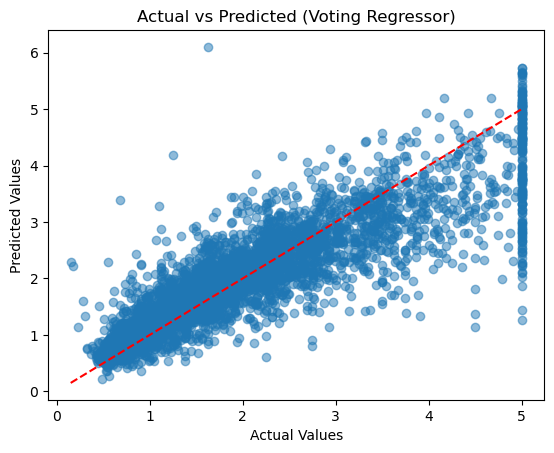

In [96]:
# Predict house prices
y_pred = voting_reg.predict(X_test_scaled)

# Plot Actual vs Predicted
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'r--')

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted (Voting Regressor)")
plt.show()

In [97]:
### Cross-validation score 
cv_scores = cross_val_score(voting_reg, X_train_scaled, y_train, cv=5, scoring='r2')
print(f"Cross-validation R² scores: {cv_scores}")
print(f"Mean CV R² score: {cv_scores.mean():.4f}")

Cross-validation R² scores: [0.7420457  0.74119289 0.74810404 0.74720692 0.74245624]
Mean CV R² score: 0.7442
